In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install timm
!pip install scikit-learn


In [3]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


In [5]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])


In [6]:
!ls /content/drive/MyDrive


 best_vit_hcc.pth  'Colab Notebooks'   mtech   nlp


In [7]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
!ls /content/drive/MyDrive/mtech


Test				 Training-20260213T113205Z-1-001.zip
Test-20260213T111402Z-1-001.zip  Validation
Training			 Validation-20260213T111425Z-1-001.zip


In [9]:
!ls /content/drive/MyDrive/mtech



Test				 Training-20260213T113205Z-1-001.zip
Test-20260213T111402Z-1-001.zip  Validation
Training			 Validation-20260213T111425Z-1-001.zip


In [10]:
!ls /content/drive/MyDrive/mtech/Training
!ls /content/drive/MyDrive/mtech/Validation
!ls /content/drive/MyDrive/mtech/Test


grade0	grade1	grade2	grade3
grade0	grade1	grade2	grade3
grade0	grade1	grade2	grade3


In [11]:
data_dir = "/content/drive/MyDrive/mtech"

train_dataset = datasets.ImageFolder(os.path.join(data_dir, "Training"), transform=transform)
val_dataset   = datasets.ImageFolder(os.path.join(data_dir, "Validation"), transform=transform)
test_dataset  = datasets.ImageFolder(os.path.join(data_dir, "Test"), transform=transform)


In [12]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

num_classes = len(train_dataset.classes)
print(train_dataset.classes)

['grade0', 'grade1', 'grade2', 'grade3']


In [13]:
model = timm.create_model("vit_large_patch16_224", pretrained=True)
model.head = nn.Identity()  # remove classifier
model = model.to(device)

for param in model.parameters():
    param.requires_grad = False


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

In [14]:
classifier = nn.Linear(1024, num_classes)  # UNI has 1024-dim features
classifier = classifier.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classifier.parameters(), lr=1e-3)


In [15]:
def train_epoch(loader):
    classifier.train()
    total_loss = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        with torch.no_grad():
            features = model(images)

        outputs = classifier(features)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


In [16]:
def evaluate(loader):
    classifier.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            features = model(images)
            outputs = classifier(features)

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro')
    recall = recall_score(all_labels, all_preds, average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')
    roc_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')

    return acc, precision, recall, f1, roc_auc, all_labels, all_preds


In [18]:
epochs = 10

for epoch in range(epochs):
    loss = train_epoch(train_loader)
    val_metrics = evaluate(val_loader)

    print(f"Epoch {epoch+1}")
    print("Loss:", loss)
    print("Val Accuracy:", val_metrics[0])


Epoch 1
Loss: 0.1794615943916142
Val Accuracy: 0.9357142857142857
Epoch 2
Loss: 0.13904929645359515
Val Accuracy: 0.9178571428571428
Epoch 3
Loss: 0.10962651695590467
Val Accuracy: 0.8785714285714286
Epoch 4
Loss: 0.0954924096353352
Val Accuracy: 0.9107142857142857
Epoch 5
Loss: 0.08492058513220399
Val Accuracy: 0.9178571428571428
Epoch 6
Loss: 0.06621352890506386
Val Accuracy: 0.9107142857142857
Epoch 7
Loss: 0.07703180250246078
Val Accuracy: 0.9035714285714286
Epoch 8
Loss: 0.05164658618159592
Val Accuracy: 0.9107142857142857
Epoch 9
Loss: 0.04960914824041538
Val Accuracy: 0.8964285714285715
Epoch 10
Loss: 0.04408731452422217
Val Accuracy: 0.9107142857142857


In [19]:
acc, precision, recall, f1, roc_auc, labels, preds = evaluate(test_loader)

print("Test Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("ROC-AUC:", roc_auc)


Test Accuracy: 0.9
Precision: 0.9173364745011087
Recall: 0.89375
F1: 0.9022266313932981
ROC-AUC: 0.9863451086956522


Confusion Matrix:
[[70  0  0  0]
 [ 0 75  5  0]
 [ 0 13 67  0]
 [ 0  0 10 40]]


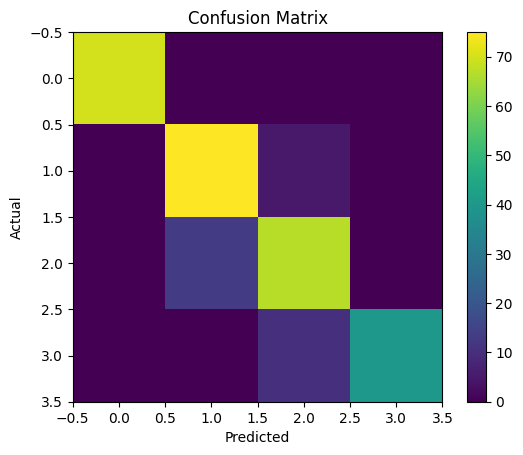

In [20]:
cm = confusion_matrix(labels, preds)
print("Confusion Matrix:")
print(cm)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()


In [21]:
from sklearn.metrics import classification_report

class_names = train_dataset.classes

report = classification_report(
    labels,
    preds,
    target_names=class_names,
    digits=4
)

print("Classification Report:\n")
print(report)


Classification Report:

              precision    recall  f1-score   support

      grade0     1.0000    1.0000    1.0000        70
      grade1     0.8523    0.9375    0.8929        80
      grade2     0.8171    0.8375    0.8272        80
      grade3     1.0000    0.8000    0.8889        50

    accuracy                         0.9000       280
   macro avg     0.9173    0.8938    0.9022       280
weighted avg     0.9055    0.9000    0.9002       280



In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(labels, preds)

print("Confusion Matrix (Raw Counts):\n")
print(cm)


Confusion Matrix (Raw Counts):

[[70  0  0  0]
 [ 0 75  5  0]
 [ 0 13 67  0]
 [ 0  0 10 40]]


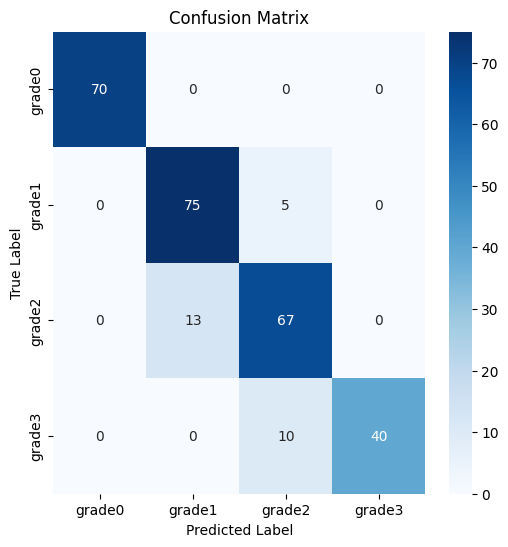

In [23]:
plt.figure(figsize=(6,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


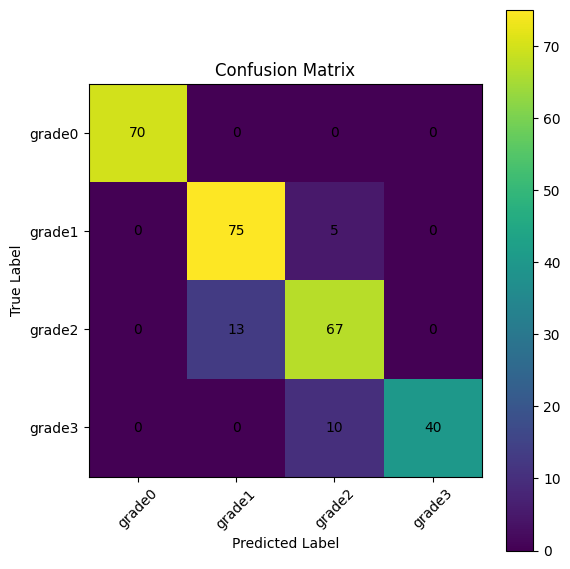

In [24]:
plt.figure(figsize=(6,6))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()


**Fine Tuned**

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(train_dataset.classes)

model = timm.create_model(
    "vit_large_patch16_224",
    pretrained=True,
    num_classes=num_classes
)

model = model.to(device)


In [26]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-5,              # small LR for fine tuning
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)


In [35]:
def train_epoch(loader):
    model.train()
    running_loss = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

In [36]:
from sklearn.metrics import accuracy_score

def evaluate(loader):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)

    return acc, all_labels, all_preds, all_probs

In [37]:
epochs = 15
best_val_acc = 0

save_path = "/content/drive/MyDrive/mtech/best_vit_hcc_finetuned.pth"

for epoch in range(epochs):

    train_loss = train_epoch(train_loader)
    val_acc, _, _, _ = evaluate(val_loader)

    scheduler.step()

    print(f"Epoch [{epoch+1}/{epochs}]")
    print("Train Loss:", train_loss)
    print("Validation Accuracy:", val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), save_path)
        print("✅ Best model saved.")

Epoch [1/15]
Train Loss: 0.24864949901589356
Validation Accuracy: 0.9285714285714286
✅ Best model saved.
Epoch [2/15]
Train Loss: 0.04999147945129158
Validation Accuracy: 0.9142857142857143
Epoch [3/15]
Train Loss: 0.042220910404013524
Validation Accuracy: 0.9035714285714286
Epoch [4/15]
Train Loss: 0.009621035952563074
Validation Accuracy: 0.9392857142857143
✅ Best model saved.
Epoch [5/15]
Train Loss: 0.000709389076117784
Validation Accuracy: 0.9392857142857143
Epoch [6/15]
Train Loss: 0.00012681416646128955
Validation Accuracy: 0.9392857142857143
Epoch [7/15]
Train Loss: 9.286540713792504e-05
Validation Accuracy: 0.9392857142857143
Epoch [8/15]
Train Loss: 7.741417440502974e-05
Validation Accuracy: 0.9392857142857143
Epoch [9/15]
Train Loss: 7.028690034818842e-05
Validation Accuracy: 0.9392857142857143
Epoch [10/15]
Train Loss: 6.731631610334339e-05
Validation Accuracy: 0.9392857142857143
Epoch [11/15]
Train Loss: 6.686557427118797e-05
Validation Accuracy: 0.9392857142857143
Epoch [

In [38]:
model.load_state_dict(torch.load(save_path))

<All keys matched successfully>

In [39]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import numpy as np

test_acc, labels, preds, probs = evaluate(test_loader)

labels = np.array(labels)
probs = np.array(probs)

print("Test Accuracy:", test_acc)

print("\nClassification Report:\n")
print(classification_report(labels, preds, target_names=train_dataset.classes))

print("\nConfusion Matrix:\n")
print(confusion_matrix(labels, preds))

roc_auc_macro = roc_auc_score(labels, probs, multi_class='ovr', average='macro')
print("\nROC-AUC (Macro OvR):", roc_auc_macro)

Test Accuracy: 0.9357142857142857

Classification Report:

              precision    recall  f1-score   support

      grade0       1.00      1.00      1.00        70
      grade1       0.86      0.93      0.89        80
      grade2       0.92      0.85      0.88        80
      grade3       1.00      1.00      1.00        50

    accuracy                           0.94       280
   macro avg       0.94      0.94      0.94       280
weighted avg       0.94      0.94      0.94       280


Confusion Matrix:

[[70  0  0  0]
 [ 0 74  6  0]
 [ 0 12 68  0]
 [ 0  0  0 50]]

ROC-AUC (Macro OvR): 0.990859375
